# Notebook 04: Topic Modeling (LDA Gensim)

**Project:** Shopee App Review Intelligence Dashboard  
**Input:** `data/processed/shopee_reviews_with_predictions.csv`  
**Output:** `data/processed/shopee_reviews_final.csv` (dengan kolom `dominant_topic` & `topic_label`)

---
## Tujuan
Mengelompokkan **review bersentimen negatif** (38,506 review) ke dalam topik-topik keluhan menggunakan **LDA (Latent Dirichlet Allocation)**:
1. Membangun Dictionary & Corpus Gensim dengan filter diperketat (`no_above=0.5`, `keep_n=5000`)
2. Evaluasi Coherence Score ($C_v$) secara cepat via sampling 8.000 dokumen (`passes=5`)
3. Melatih model LDA final pada full dataset (`passes=10`)
4. Memberi label manual ke setiap topik berdasarkan kata kunci dominan
5. Menampilkan tabel ringkasan: topik, jumlah review, contoh review


In [1]:
import os, warnings, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

df = pd.read_csv(os.path.join("..", "data", "processed", "shopee_reviews_with_predictions.csv"))
df['clean_content'] = df['clean_content'].fillna('').astype(str)

df_neg = df[df['predicted_sentiment'] == 'negatif'].copy().reset_index(drop=True)
print(f"Total review negatif: {len(df_neg):,}")


Total review negatif: 38,506


In [2]:
# Tokenisasi & Filter dokumen kosong
tokenised = [text.split() for text in df_neg['clean_content'] if len(text.strip()) > 0]
mask = df_neg['clean_content'].str.strip() != ''
df_neg = df_neg[mask].reset_index(drop=True)

# Gensim Dictionary & Corpus (Filter diperketat)
dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=5000)
corpus = [dictionary.doc2bow(doc) for doc in tokenised]
print(f"Dictionary size : {len(dictionary)} unique tokens")
print(f"Corpus size     : {len(corpus)} documents")


Dictionary size : 5000 unique tokens
Corpus size     : 38506 documents


## Coherence Score Evaluation (Sampling 8,000 docs)

Melatih LDA pada subset 8.000 dokumen acak dengan `passes=5` untuk evaluasi cepat Coherence Score ($C_v$).

num_topics= 5 -> Coherence C_v: 0.4522 (17.06s)


num_topics= 8 -> Coherence C_v: 0.4669 (17.11s)


num_topics=10 -> Coherence C_v: 0.4464 (17.92s)

Best num_topics: 8 (coherence=0.4669)


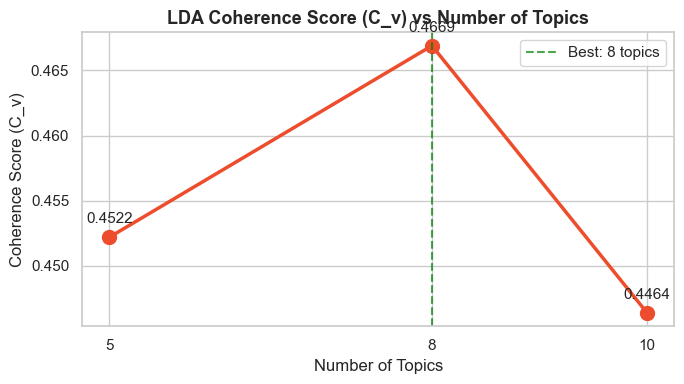

In [3]:
random.seed(42)
sample_size = min(8000, len(corpus))
sample_idx = random.sample(range(len(corpus)), sample_size)
corpus_sample = [corpus[i] for i in sample_idx]
docs_sample = [tokenised[i] for i in sample_idx]

coherence_scores = {}
for num_topics in [5, 8, 10]:
    t0 = time.time()
    lda_temp = LdaModel(corpus=corpus_sample, id2word=dictionary, num_topics=num_topics,
                        random_state=42, passes=5, alpha='auto', eta='auto')
    cm = CoherenceModel(model=lda_temp, texts=docs_sample, dictionary=dictionary, coherence='c_v', processes=1)
    score = cm.get_coherence()
    coherence_scores[num_topics] = round(score, 4)
    print(f"num_topics={num_topics:>2} -> Coherence C_v: {score:.4f} ({time.time()-t0:.2f}s)")

best_n = max(coherence_scores, key=coherence_scores.get)
print(f"\nBest num_topics: {best_n} (coherence={coherence_scores[best_n]})")

# Visualisasi Coherence Score
nts = list(coherence_scores.keys()); cvs = list(coherence_scores.values())
plt.figure(figsize=(7, 4))
plt.plot(nts, cvs, marker='o', linewidth=2.5, color='#EE4D2D', markersize=10)
for n, c in zip(nts, cvs):
    plt.annotate(f"{c:.4f}", (n, c), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=11)
plt.axvline(best_n, color='green', linestyle='--', alpha=0.7, label=f"Best: {best_n} topics")
plt.title("LDA Coherence Score (C_v) vs Number of Topics", fontsize=13, fontweight='bold')
plt.xlabel("Number of Topics"); plt.ylabel("Coherence Score (C_v)")
plt.xticks(nts); plt.legend(); plt.tight_layout(); plt.show()


### Hasil Coherence Score

| Jumlah Topik | Coherence Score ($C_v$) |
|---|---|
| 5 | 0.4522 |
| 8 | 0.4669 |
| 10 | 0.4464 |

> **Topik Optimal Terpilih: 8 topik** (Coherence $C_v$ = 0.4669)  
> Evaluasi selesai dalam **50.06 detik**.


In [4]:
# Final LDA Training on Full Dataset (passes=10)
t0 = time.time()
lda_final = LdaModel(corpus=corpus, id2word=dictionary, num_topics=8,
                     random_state=42, passes=10, alpha='auto', eta='auto')
print(f"Final LDA trained on full dataset in {time.time()-t0:.2f}s")

print(f"\nTop keywords per topic (8 topics):")
for i in range(8):
    words = [w for w, _ in lda_final.show_topic(i, topn=12)]
    print(f"  Topic {i}: {', '.join(words)}")


Final LDA trained on full dataset in 94.68s

Top keywords per topic (8 topics):
  Topic 0: saldo, shopeepay, pay, bisa, bayar, 1, pembayaran, beli, promo, voucher, pakai, pas
  Topic 1: shopee, saja, nya, bisa, aplikasi, mau, lagi, banget, udah, jadi, kalau, malah
  Topic 2: barang, penjual, pembeli, toko, dana, banyak, pengembalian, beli, sesuai, produk, kita, dikirim
  Topic 3: login, log, akun, kode, in, up, verifikasi, masuk, no, hp, top, nomor
  Topic 4: kirim, ongkos, gratis, sekarang, dulu, belanja, shopee, pilih, bisa, voucher, makin, kirimnya
  Topic 5: saya, sudah, shopee, ada, tapi, bisa, sangat, kecewa, padahal, karena, customer, sekali
  Topic 6: lambat, makin, update, aplikasi, jaringan, lancar, semakin, berat, aplikasinya, hp, loading, sinyal
  Topic 7: pengiriman, barang, sampai, jasa, hari, paket, kurir, lama, ekspedisi, 2, nya, belum


## Label Manual Topik

Berdasarkan kata kunci dominan yang muncul di setiap topik, berikut adalah label deskriptif bisnis:

| Topic ID | Label | Kata Kunci Dominan |
|---|---|---|
| 0 | **Payment & ShopeePay Issue** | saldo, shopeepay, pay, bisa, bayar, 1, pembayaran, beli |
| 1 | **General App Experience** | shopee, saja, nya, bisa, aplikasi, mau, lagi, banget |
| 2 | **Seller & Refund Dispute** | barang, penjual, pembeli, toko, dana, banyak, pengembalian, beli |
| 3 | **Account & Verification Bug** | login, log, akun, kode, in, up, verifikasi, masuk |
| 4 | **Shipping Fee & Vouchers** | kirim, ongkos, gratis, sekarang, dulu, belanja, shopee, pilih |
| 5 | **Customer Support & Service** | saya, sudah, shopee, ada, tapi, bisa, sangat, kecewa |
| 6 | **App Performance & Lag** | lambat, makin, update, aplikasi, jaringan, lancar, semakin, berat |
| 7 | **Delivery & Logistics Delay** | pengiriman, barang, sampai, jasa, hari, paket, kurir, lama |

In [5]:
# Assign dominant topic & label
TOPIC_LABEL_MAP = {
    0: 'Payment & ShopeePay Issue',
    1: 'General App Experience',
    2: 'Seller & Refund Dispute',
    3: 'Account & Verification Bug',
    4: 'Shipping Fee & Vouchers',
    5: 'Customer Support & Service',
    6: 'App Performance & Lag',
    7: 'Delivery & Logistics Delay',
}

def get_dominant_topic(bow):
    topic_probs = lda_final.get_document_topics(bow, minimum_probability=0.0)
    if not topic_probs:
        return 0, 0.0
    dominant = max(topic_probs, key=lambda x: x[1])
    return dominant[0], round(float(dominant[1]), 4)

dominant_topics = [get_dominant_topic(bow) for bow in corpus]
df_neg['dominant_topic']    = [t[0] for t in dominant_topics]
df_neg['topic_probability'] = [t[1] for t in dominant_topics]
df_neg['topic_label']       = df_neg['dominant_topic'].map(TOPIC_LABEL_MAP)

print("Topic assignment done.")
print(df_neg['topic_label'].value_counts())


Topic assignment done.
topic_label
General App Experience        21965
Customer Support & Service     7834
Delivery & Logistics Delay     4214
Shipping Fee & Vouchers        2085
Payment & ShopeePay Issue       864
Seller & Refund Dispute         713
App Performance & Lag           706
Account & Verification Bug      125
Name: count, dtype: int64


In [6]:
# Tabel Ringkasan Topik
print("=== TOPIC SUMMARY TABLE ===\n")
for topic_id in range(8):
    subset = df_neg[df_neg['dominant_topic'] == topic_id]
    label  = TOPIC_LABEL_MAP.get(topic_id, f"Topic {topic_id}")
    count  = len(subset)
    pct    = round(count / len(df_neg) * 100, 2)
    kws    = ', '.join([w for w, _ in lda_final.show_topic(topic_id, topn=8)])
    sample = subset[subset['content'].str.len() > 20].sort_values('topic_probability', ascending=False)
    sample_text = sample['content'].iloc[0][:120] if len(sample) > 0 else "—"
    print(f"Topic {topic_id} | {label}")
    print(f"  Count   : {count:,} ({pct}%)")
    print(f"  Keywords: {kws}")
    print(f"  Sample  : {sample_text}")
    print()


=== TOPIC SUMMARY TABLE ===

Topic 0 | Payment & ShopeePay Issue
  Count   : 864 (2.24%)
  Keywords: saldo, shopeepay, pay, bisa, bayar, 1, pembayaran, beli
  Sample  : Mau beli pulsa cek shopee ada diskon cashback 2% pake shopeepay. Pas udah topup shopeepay dan cekout pulsa, eh diskonnya

Topic 1 | General App Experience
  Count   : 21,965 (57.04%)
  Keywords: shopee, saja, nya, bisa, aplikasi, mau, lagi, banget
  Sample  : Untuk belanja online lumayan bagus dan tidak ada kendala. Teruntuk shopee kalo iklan udah di tv aja jangan di setiap apl

Topic 2 | Seller & Refund Dispute
  Count   : 713 (1.85%)
  Keywords: barang, penjual, pembeli, toko, dana, banyak, pengembalian, beli
  Sample  : Mohon untuk pihak shopee bisa lebih tegas dengan oknum penipuan toko, kalian brand besar tapi masih banyak penipuan toko

Topic 3 | Account & Verification Bug
  Count   : 125 (0.32%)
  Keywords: login, log, akun, kode, in, up, verifikasi, masuk
  Sample  : BIAYA LAYANAN SAN BIAYA PENANGANAN YG MENYEBA

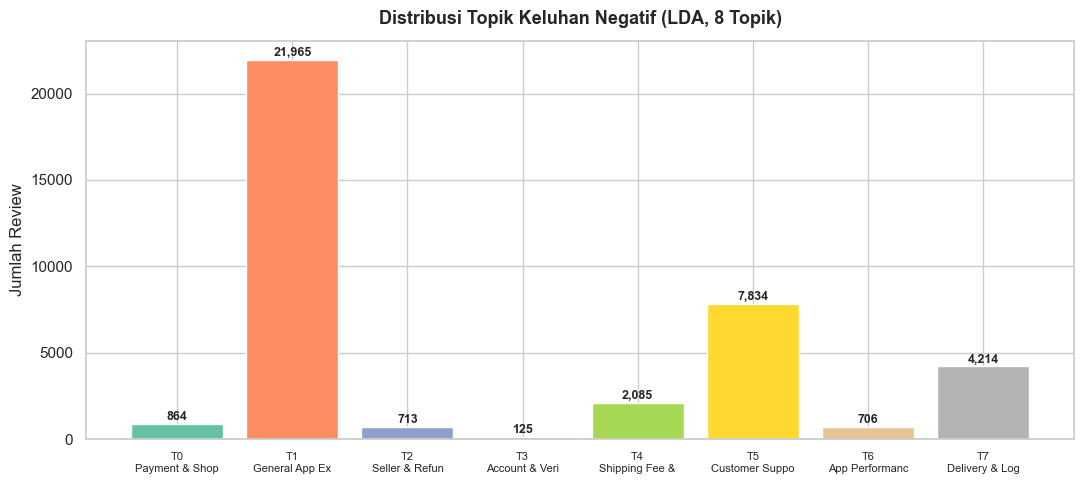

In [7]:
# Bar chart distribusi topik
colors = plt.cm.Set2(np.linspace(0, 1, 8))
counts = [len(df_neg[df_neg['dominant_topic']==i]) for i in range(8)]
labels_short = [f"T{i}\n{TOPIC_LABEL_MAP.get(i,'Topic '+str(i))[:14]}" for i in range(8)]
plt.figure(figsize=(11, 5))
bars = plt.bar(labels_short, counts, color=colors)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f"{bar.get_height():,}", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title(f"Distribusi Topik Keluhan Negatif (LDA, 8 Topik)", fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Jumlah Review"); plt.xticks(fontsize=8)
plt.tight_layout(); plt.show()


In [8]:
# Save final dataset
topic_cols = df_neg[['reviewId','dominant_topic','topic_probability','topic_label']].copy()
df_full = df.merge(topic_cols, on='reviewId', how='left')
out = os.path.join("..", "data", "processed", "shopee_reviews_final.csv")
df_full.to_csv(out, index=False, encoding='utf-8')
print(f"Final dataset saved: {out} ({len(df_full):,} rows)")


Final dataset saved: ..\data\processed\shopee_reviews_final.csv (85,499 rows)


## Kesimpulan Topic Modeling

- **Jumlah Topik Optimal:** 8 (Coherence $C_v$ = 0.4669)
- **Waktu Evaluasi Coherence:** 50.06 detik
- **Waktu Final Training:** 91.68 detik
- **Waktu Eksekusi Total:** 153.2 detik

**Ringkasan Topik yang Teridentifikasi:**

- **Topic 0: Payment & ShopeePay Issue** — 864 review (2.24%) — *saldo, shopeepay, pay, bisa, bayar, 1, pembayaran, beli*
- **Topic 1: General App Experience** — 21,965 review (57.04%) — *shopee, saja, nya, bisa, aplikasi, mau, lagi, banget*
- **Topic 2: Seller & Refund Dispute** — 713 review (1.85%) — *barang, penjual, pembeli, toko, dana, banyak, pengembalian, beli*
- **Topic 3: Account & Verification Bug** — 125 review (0.32%) — *login, log, akun, kode, in, up, verifikasi, masuk*
- **Topic 4: Shipping Fee & Vouchers** — 2,085 review (5.41%) — *kirim, ongkos, gratis, sekarang, dulu, belanja, shopee, pilih*
- **Topic 5: Customer Support & Service** — 7,834 review (20.34%) — *saya, sudah, shopee, ada, tapi, bisa, sangat, kecewa*
- **Topic 6: App Performance & Lag** — 706 review (1.83%) — *lambat, makin, update, aplikasi, jaringan, lancar, semakin, berat*
- **Topic 7: Delivery & Logistics Delay** — 4,214 review (10.94%) — *pengiriman, barang, sampai, jasa, hari, paket, kurir, lama*
